# Cartel Network Evolution in Mexico, 2018–2024

The `cartel_network/BACRIM2020_*` files give us a single **static snapshot**, around 2020, of which cartels ally and which ones fight. They tell us nothing about *when* a rivalry started, escalated, or faded. The `LATAM 20241209.csv` ACLED event file, on the other hand, has a real time axis — every recorded clash, killing, and bombing in Mexico from 2018 through 2024, dated and geolocated, with the armed groups involved named in `actor1`/`actor2`.

This notebook turns that event stream into a **temporal network**: for every year, who fought whom, how often, and where. The data structure underneath is a temporal edge list — rows of `(year, cartel_a, cartel_b, clash_count, fatalities)` — which is what lets us render the network as a sequence of yearly snapshots instead of one frozen picture.

The notebook has three parts:
1. **Build the temporal network** from raw ACLED actor names (name normalization, filtering, edge construction).
2. **The national picture** — small-multiples of the whole Mexico cartel clash network, one panel per year, on a fixed layout so you can watch it evolve.
3. **Cartel walkthroughs** — for a chosen cartel, its geographic footprint by year on a map of Mexico, plus who it was fighting each year. Applied here to CJNG (national expansion) and Cartel del Noreste (regional war and decline) as two contrasting stories; any other cartel in the network can be substituted.

## 1. Setup

In [1]:
import re

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import plotly.express as px

pd.set_option("display.width", 160)

# Categorical / sequential palette (dataviz skill reference palette, light-mode values).
# BLUE marks "the cartel we're following" throughout this notebook; RED marks civilian-targeting
# violence specifically; the rest are ordinary categorical slots for rivals/other series.
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948",
)
MUTED = "#c3c2b7"
INK = "#0b0b0b"
SECONDARY_INK = "#52514e"

In [2]:
# ACLED is too large to hold in memory in full (273MB / ~434k rows across all of LATAM);
# stream it in chunks and keep only Mexico with the columns this analysis needs.
cols = [
    "country", "event_date", "year", "event_type", "sub_event_type", "actor1", "actor2",
    "inter1", "inter2", "admin1", "location", "latitude", "longitude", "fatalities",
]
chunks = pd.read_csv("LATAM 20241209.csv", usecols=cols, chunksize=200_000)
mex = pd.concat([c[c["country"] == "Mexico"] for c in chunks], ignore_index=True)
mex["event_date"] = pd.to_datetime(mex["event_date"])

print(f"Mexico events, {mex['year'].min()}–{mex['year'].max()}: {len(mex):,}")
mex["event_type"].value_counts()

FileNotFoundError: [Errno 2] No such file or directory: 'LATAM 20241209.csv'

## 2. Building the temporal network

### Cartel name normalization

ACLED's `actor1`/`actor2` fields are free text: `"CJNG: Jalisco New Generation Cartel"`, `"Sinaloa Cartel"`, `"CDN: Cartel del Noreste"`. To build a network we need one canonical name per cartel. The approach:

- Strip ACLED's leading acronym tag (`"CJNG: "`), trailing year-range tags (`"(2018-)"`), the `"(Mexico)"` country suffix, and generic `"Cartel"/"Gang"/"Group"` suffixes.
- Map a handful of recurring cases to one consistent label (e.g. both `"Sinaloa"` and `"Sinaloa Cartel"` → `"Sinaloa Cartel"`).
- Keep only actors ACLED tags `inter = "Political militia"` — its category for organized armed groups. This also filters out political parties, which ACLED tags the same way when they clash at the ballot box, so we exclude those explicitly by name (PRI, PRD, MORENA, etc.), along with police/military/self-defense/community-militia actors, which are state or civilian actors, not cartels.

This is a heuristic, not a verified entity-resolution pipeline — it will miss aliases and occasionally rename a group inconsistently across sources. Treat cartel identity here as "best available from the text," not ground truth.

In [ ]:
EXCLUDE_PATTERNS = [
    r"^Unidentified", r"^Police Forces", r"^Military Forces", r"^Self-Defense",
    r"Communal Militia", r"^Civilians", r"National Guard", r"^Protesters",
    r"^Rioters", r"Health Workers", r"Government of Mexico", r"^Journalists",
    r"Policia Comunitaria", r"^Rebel Group", r"Prison Guards",
    # political parties/coalitions -- ACLED still tags these "Political militia" when they clash
    r"^(PRI|PRD|PAN|MORENA|MC|PT|PVEM|PES|RSP|FXM):",
    r"Institutional Revolutionary Party", r"Party of the Democratic Revolution",
    r"National Regeneration Movement", r"Strength and Heart for Mexico",
    r"National Action Party", r"Broad Front for Mexico", r"Citizens Movement",
    r"Labor Party \(Mexico\)", r"Ecologist Green Party",
]
EXCLUDE_RE = re.compile("|".join(EXCLUDE_PATTERNS))

CANON = {
    "Jalisco New Generation": "CJNG", "Sinaloa": "Sinaloa Cartel",
    "CDN": "Cartel del Noreste", "Golfo": "Gulf Cartel (Golfo)", "Gulf": "Gulf Cartel (Golfo)",
    "Los Chapitos": "Los Chapitos (Sinaloa)", "CU": "Carteles Unidos", "United Cartels": "Carteles Unidos",
    "Los Caballeros Templarios": "Caballeros Templarios",
}


def clean_name(name):
    if pd.isna(name):
        return None
    n = name.strip()
    n = re.sub(r"^[A-Z0-9]{2,6}:\s*", "", n)
    n = re.sub(r"\s*\(\d{4}-?\d*\)\s*", " ", n)
    n = re.sub(r"\s*\(Mexico\)\s*", " ", n)
    n = re.sub(r"\s+(Cartel|Gang|Group)$", "", n).strip()
    return n


def canon_name(raw):
    if pd.isna(raw) or EXCLUDE_RE.search(raw):
        return None
    c = clean_name(raw)
    return CANON.get(c, c)


for col in ["actor1", "actor2"]:
    mex[col + "_canon"] = mex[col].apply(canon_name)
    inter_col = "inter1" if col == "actor1" else "inter2"
    mex.loc[mex[inter_col] != "Political militia", col + "_canon"] = None

named = mex["actor1_canon"].notna()
print(f"Events with a named cartel as actor1: {named.sum():,} of {len(mex):,}")
mex.loc[named, "actor1_canon"].value_counts().head(20)

Events with a named cartel as actor1: 2,753 of 95,647


actor1_canon
CJNG                      899
Huachicoleros             222
Sinaloa Cartel            221
Cartel del Noreste        153
La Familia Michoacana     147
Santa Rosa de Lima        126
Los Viagras                97
Gulf Cartel (Golfo)        69
Los Chapitos (Sinaloa)     53
La Union Tepito            48
Los Ardillos               39
La Linea                   30
La Barredora               28
Tropa del Infierno         25
Los Escorpiones            21
Los Metros                 21
Grupo Elite                20
Carteles Unidos            20
Los Tlacos                 17
Grupo Sombra               16
Name: count, dtype: int64

### Temporal edge list and geographic activity table

Two tables come out of the normalized data:

- **`yearly_edges`**: for `Battles` events where *both* sides are named cartels, one row per `(year, cartel_a, cartel_b)` pair with the clash count and total fatalities that year. This is the network.
- **`geo`**: every violent event (battles, violence against civilians, explosions) involving a named cartel on either side, with its date, location and fatalities. This drives the geographic walkthroughs.

The network is capped to cartels with at least 3 recorded clashes across the full 2018–2024 window — below that, a single-incident "rivalry" is more noise than signal, and it keeps the small-multiples panels readable.

In [ ]:
battles = mex[mex["event_type"] == "Battles"].copy()
both_named = battles["actor1_canon"].notna() & battles["actor2_canon"].notna()
clash = battles[both_named & (battles["actor1_canon"] != battles["actor2_canon"])].copy()
clash["pair"] = clash.apply(lambda r: tuple(sorted([r["actor1_canon"], r["actor2_canon"]])), axis=1)
clash[["a", "b"]] = pd.DataFrame(clash["pair"].tolist(), index=clash.index)

yearly_edges = (
    clash.groupby(["year", "a", "b"])
    .agg(weight=("pair", "size"), fatalities=("fatalities", "sum"))
    .reset_index()
)

deg = pd.concat([
    yearly_edges.groupby("a")["weight"].sum(),
    yearly_edges.groupby("b")["weight"].sum(),
]).groupby(level=0).sum().sort_values(ascending=False)
KEEP = set(deg[deg >= 3].index)
yearly_edges = yearly_edges[yearly_edges["a"].isin(KEEP) & yearly_edges["b"].isin(KEEP)]

print(f"Cartels in the clash network (>=3 clashes, 2018-2024): {len(KEEP)}")
print(f"Yearly edge rows: {len(yearly_edges)}")
print("\nMost active cartels by total clashes, 2018-2024:")
deg.head(15)

Cartels in the clash network (>=3 clashes, 2018-2024): 36
Yearly edge rows: 105

Most active cartels by total clashes, 2018-2024:


CJNG                      251
Sinaloa Cartel            115
Los Viagras                46
Cartel del Noreste         42
Gulf Cartel (Golfo)        37
Carteles Unidos            30
Los Chapitos (Sinaloa)     26
Santa Rosa de Lima         21
Caballeros Templarios      19
La Familia Michoacana      18
La Linea                   17
Los Mayitos                15
Los Metros                 14
Los Escorpiones            10
Los Tlacos                  9
Name: weight, dtype: int64

In [ ]:
violent = mex[mex["event_type"].isin(["Battles", "Violence against civilians", "Explosions/Remote violence"])]
geo_cols = ["year", "admin1", "location", "latitude", "longitude", "fatalities", "event_type", "event_date"]
a1 = violent[violent["actor1_canon"].notna()][geo_cols + ["actor1_canon"]].rename(columns={"actor1_canon": "cartel"})
a2 = violent[violent["actor2_canon"].notna()][geo_cols + ["actor2_canon"]].rename(columns={"actor2_canon": "cartel"})
geo = pd.concat([a1, a2], ignore_index=True)

print(f"Geo-tagged violent-event rows involving a named cartel: {len(geo):,}")

Geo-tagged violent-event rows involving a named cartel: 3,289


### Cross-check against the static 2020 rivalry snapshot

Before trusting the derived network, it's worth checking it against `BACRIM2020_Rivals.csv` — an independently compiled, single-point-in-time rivalry map. If our ACLED-derived clashes for a well-documented cartel line up with BACRIM's known rivals, that's a good sign the name normalization and filtering are doing their job.

In [ ]:
bacrim_nodes = pd.read_csv("cartel_network/BACRIM2020_Nodes.csv")
bacrim_rivals = pd.read_csv("cartel_network/BACRIM2020_Rivals.csv")

cjng_id = bacrim_nodes.loc[bacrim_nodes["Group"].str.contains("Jalisco Nueva", na=False), "Node"].iloc[0]
documented_rivals = (
    bacrim_rivals[bacrim_rivals["Node"] == cjng_id][["RGroup", "weight"]]
    .sort_values("weight", ascending=False)
    .rename(columns={"RGroup": "documented rival (BACRIM, ~2020)", "weight": "documented weight"})
)

derived_rivals = (
    pd.concat([
        yearly_edges[yearly_edges["a"] == "CJNG"].rename(columns={"b": "rival"}),
        yearly_edges[yearly_edges["b"] == "CJNG"].rename(columns={"a": "rival"}),
    ])
    .groupby("rival")["weight"].sum()
    .sort_values(ascending=False)
    .rename("derived clashes, 2018-2024 (ACLED)")
)

print("BACRIM's documented CJNG rivals (static 2020 snapshot):")
display(documented_rivals.head(8))
print("\nThis notebook's ACLED-derived CJNG rivals, summed across 2018-2024:")
display(derived_rivals.head(8))

BACRIM's documented CJNG rivals (static 2020 snapshot):


,"documented rival (BACRIM, ~2020)",documented weight
0,La Nueva Familia Michoacana,13
3,Cártel de Sinaloa,7
5,Cártel del Noreste,6
6,Cárteles Unidos,6
11,Los Mayas,4
20,Caballeros Templarios,3
21,Cártel de Tláhuac,3
22,Cártel Nueva Plaza,3



This notebook's ACLED-derived CJNG rivals, summed across 2018-2024:


rival
Sinaloa Cartel           86
Los Viagras              39
Carteles Unidos          29
Santa Rosa de Lima       18
Caballeros Templarios    14
La Familia Michoacana    11
Gulf Cartel (Golfo)       8
Pajaros Sierra            6
Name: derived clashes, 2018-2024 (ACLED), dtype: int64

The top of both lists agree — Sinaloa Cartel, Cartel del Noreste, Carteles Unidos, Caballeros Templarios, Los Viagras all show up as CJNG rivals in both the static snapshot and the independently derived event data. The static file just can't tell you *when*; that's what the rest of this notebook adds.

## 3. How the national cartel network evolved, 2018–2024

To make the panels comparable year over year, every cartel gets **one fixed position** across all seven panels, computed once from the union of all clashes 2018–2024 (`kamada_kawai_layout`, which spaces nodes by graph-theoretic distance rather than raw edge weight — useful here since a couple of edges, like CJNG–Sinaloa, are an order of magnitude heavier than the rest and would otherwise collapse the whole layout into a single dense clump). A cartel only appears in a given year's panel if it had a recorded clash that year; its position never moves between panels, so growth, persistence and disappearance are all visible as motion (or its absence) across the sequence.

In [ ]:
G_all = nx.Graph()
G_all.add_nodes_from(KEEP)
for _, r in yearly_edges.groupby(["a", "b"])["weight"].sum().reset_index().iterrows():
    G_all.add_edge(r["a"], r["b"], weight=r["weight"])

giant_nodes = max(nx.connected_components(G_all), key=len)
pos_kk = nx.kamada_kawai_layout(G_all.subgraph(giant_nodes))
xs = np.array([p[0] for p in pos_kk.values()])
ys = np.array([p[1] for p in pos_kk.values()])
xr, yr = (xs.max() - xs.min()) or 1, (ys.max() - ys.min()) or 1
pos = {n: (2 * (x - xs.min()) / xr - 1, 2 * (y - ys.min()) / yr - 1) for n, (x, y) in pos_kk.items()}

# small disconnected components (cartels that only ever clashed with each other, never with the
# main network) get parked off to the side rather than distorting the main layout's scale
side_x, side_y = 1.35, -1.15
for comp in nx.connected_components(G_all):
    if comp == set(giant_nodes):
        continue
    for n in comp:
        pos[n] = (side_x, side_y)
        side_y += 0.22

HIGHLIGHT = {"CJNG": BLUE, "Sinaloa Cartel": ORANGE, "Cartel del Noreste": AQUA}
years = sorted(yearly_edges["year"].unique())

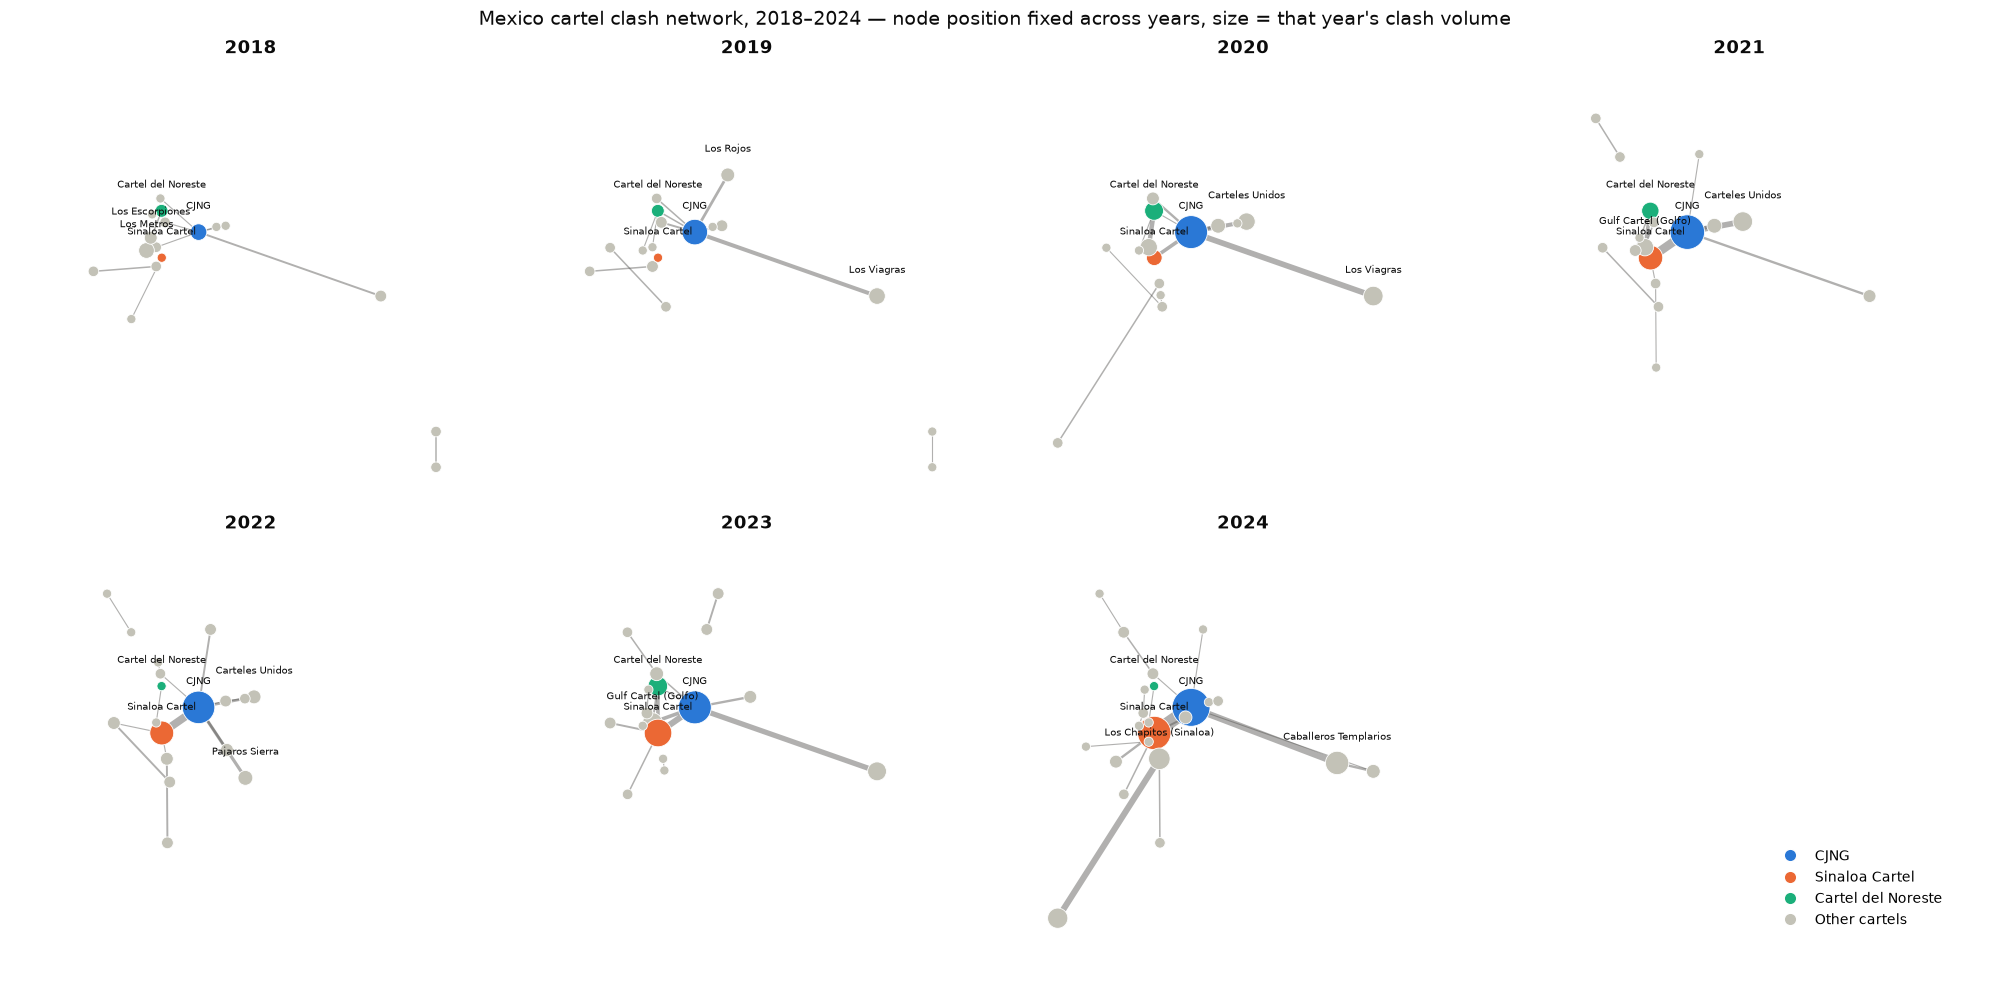

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, yr in enumerate(years):
    ax = axes[i]
    ye = yearly_edges[yearly_edges["year"] == yr]
    Gy = nx.Graph()
    for _, r in ye.iterrows():
        Gy.add_edge(r["a"], r["b"], weight=r["weight"])
    node_activity = pd.concat([ye.groupby("a")["weight"].sum(), ye.groupby("b")["weight"].sum()]).groupby(level=0).sum()

    sub_pos = {n: pos[n] for n in Gy.nodes if n in pos}
    node_colors = [HIGHLIGHT.get(n, MUTED) for n in Gy.nodes]
    node_sizes = [30 + 14 * node_activity.get(n, 1) for n in Gy.nodes]
    edge_widths = [0.5 + 0.3 * d["weight"] for _, _, d in Gy.edges(data=True)]

    nx.draw_networkx_edges(Gy, sub_pos, ax=ax, width=edge_widths, edge_color=SECONDARY_INK, alpha=0.45)
    nx.draw_networkx_nodes(Gy, sub_pos, ax=ax, node_color=node_colors, node_size=node_sizes,
                            edgecolors="white", linewidths=0.6)
    top4_this_year = node_activity.sort_values(ascending=False).head(4).index
    labels = {n: n for n in Gy.nodes if n in HIGHLIGHT or n in top4_this_year}
    label_pos = {n: (x, y + 0.16) for n, (x, y) in sub_pos.items() if n in labels}
    nx.draw_networkx_labels(Gy, label_pos, labels=labels, ax=ax, font_size=7.5, font_color=INK)

    ax.set_title(str(yr), fontsize=13, color=INK, fontweight="bold")
    ax.axis("off")
    ax.set_xlim(-1.35, 1.7)
    ax.set_ylim(-1.35, 1.35)

for j in range(len(years), len(axes)):
    axes[j].axis("off")

legend_handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=9, label=n)
                   for n, c in HIGHLIGHT.items()]
legend_handles.append(plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=MUTED, markersize=9, label="Other cartels"))
fig.legend(handles=legend_handles, loc="lower right", bbox_to_anchor=(0.98, 0.05), frameon=False, fontsize=10)

fig.suptitle("Mexico cartel clash network, 2018–2024 — node position fixed across years, size = that year's clash volume",
             fontsize=14, color=INK)
plt.tight_layout()
plt.show()

In [ ]:
national_trend = yearly_edges.groupby("year").agg(
    clashes=("weight", "sum"), fatalities=("fatalities", "sum"),
    active_cartels=("a", lambda s: len(set(s) | set(yearly_edges.loc[s.index, "b"]))),
)
national_trend

,clashes,fatalities,active_cartels
year,,,
2018,22,38,17
2019,31,87,17
2020,53,161,15
2021,60,235,17
2022,50,183,18
2023,64,105,17
2024,86,218,23


**What the sequence shows:** CJNG (blue) sits at the center of the network in every single year from 2018 on — it is never just one player among many, it is the hub the rest of the map organizes around. Its rivalry with Sinaloa Cartel (orange) is the one edge present in nearly every panel, and it thickens sharply in the later years, consistent with the totals above. The cast of secondary rivals keeps turning over — Los Rojos and Los Metros show up in 2018–2019, Carteles Unidos becomes prominent 2020–2022, Caballeros Templarios erupts as a major new front in 2024 — which reads as CJNG opening (or losing) fronts across the country rather than fighting one static war. Cartel del Noreste (aqua) stays visibly peripheral in every panel: present, but never central to the CJNG–Sinaloa axis — its own war (below) is happening elsewhere on the map, literally.

## 4. Walking a cartel through time

Two reusable views for any cartel in `KEEP`:

- **`cartel_geo_story`** — small-multiples map of Mexico, one panel per year, plotting every violent event that cartel was party to. Bubble size is fatalities; color is event type.
- **`cartel_rivals_by_year`** — a stacked bar of clash volume per year, broken out by opponent, answering "who were they actually fighting, and did that change."

Together they tie the geography to the network: where a cartel's footprint moved, and who was contesting it while it did.

In [ ]:
EVENT_COLORS = {"Battles": BLUE, "Violence against civilians": RED, "Explosions/Remote violence": ORANGE}
RIVAL_COLORS = [ORANGE, AQUA, YELLOW, MUTED]


def cartel_geo_story(cartel, top=None):
    d = geo[geo["cartel"] == cartel].dropna(subset=["latitude", "longitude"]).sort_values("year")
    fig = px.scatter_geo(
        d, lat="latitude", lon="longitude", color="event_type", size="fatalities",
        size_max=18, facet_col="year", facet_col_wrap=4, color_discrete_map=EVENT_COLORS,
        hover_name="location",
        hover_data={"admin1": True, "fatalities": True, "latitude": False, "longitude": False,
                     "event_type": False, "year": False},
        title=f"{cartel} — geographic footprint by year",
    )
    fig.update_geos(
        scope="north america", lataxis_range=[13, 34], lonaxis_range=[-119, -85],
        showcountries=True, countrycolor=MUTED, showland=True, landcolor="#f4f3f0",
        showocean=True, oceancolor="#eef3f8", showsubunits=True, subunitcolor="#e1e0d9", resolution=50,
    )
    fig.update_traces(marker=dict(line=dict(width=0.4, color="white")))
    fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
    fig.update_layout(height=520, width=1400, legend_title_text="Event type",
                       margin=dict(t=70, l=0, r=0, b=0), font=dict(family="system-ui, sans-serif"))
    return fig, d


def cartel_rivals_by_year(cartel, top_n=3):
    sub = yearly_edges[(yearly_edges["a"] == cartel) | (yearly_edges["b"] == cartel)].copy()
    sub["rival"] = np.where(sub["a"] == cartel, sub["b"], sub["a"])
    totals = sub.groupby("rival")["weight"].sum().sort_values(ascending=False)
    top_rivals = list(totals.head(top_n).index)
    sub["rival_bucket"] = np.where(sub["rival"].isin(top_rivals), sub["rival"], "Other rivals")
    pivot = sub.groupby(["year", "rival_bucket"])["weight"].sum().unstack(fill_value=0)
    order = top_rivals + (["Other rivals"] if "Other rivals" in pivot.columns else [])
    return pivot.reindex(columns=order, fill_value=0).reindex(index=years, fill_value=0)


def plot_rivals_bar(cartel, pivot):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    bottom = np.zeros(len(pivot))
    for i, col in enumerate(pivot.columns):
        ax.bar(pivot.index.astype(str), pivot[col], bottom=bottom, color=RIVAL_COLORS[i % len(RIVAL_COLORS)],
               label=col, width=0.6)
        bottom += pivot[col].values
    ax.set_title(f"{cartel} — recorded clashes by rival, per year", color=INK, fontsize=13)
    ax.set_ylabel("Clash events", color=SECONDARY_INK)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(colors=SECONDARY_INK)
    ax.legend(frameon=False, loc="upper left")
    plt.tight_layout()
    plt.show()

### CJNG: relentless national expansion

Every cartel tracked in `KEEP` (36 of them) can be substituted into the two calls below — e.g. `cartel_geo_story("Los Zetas")`. Starting with CJNG, since the network view above already marks it as the dominant hub.

In [ ]:
fig, cjng_geo = cartel_geo_story("CJNG")
fig.show()

cjng_geo.groupby("year").agg(events=("cartel", "size"), states=("admin1", "nunique"), fatalities=("fatalities", "sum"))

,events,states,fatalities
year,,,
2018,78,15,144
2019,114,19,255
2020,180,16,322
2021,185,13,335
2022,131,15,283
2023,133,14,199
2024,127,17,243


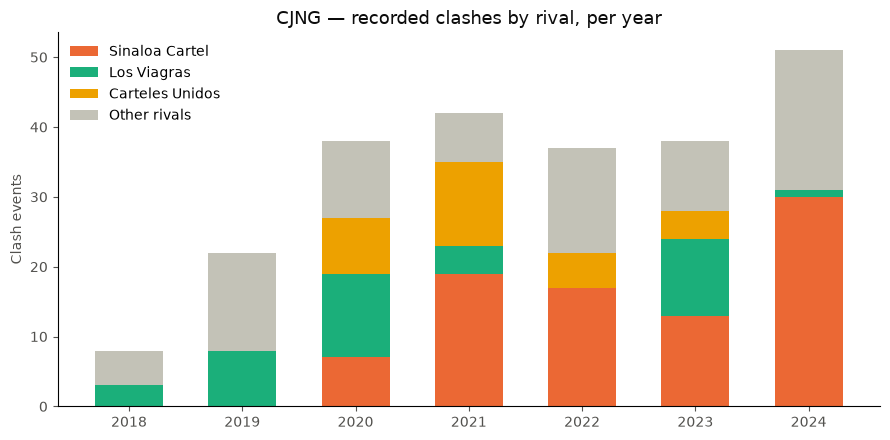

rival_bucket,Sinaloa Cartel,Los Viagras,Carteles Unidos,Other rivals
year,,,,
2018,0,3,0,5
2019,0,8,0,14
2020,7,12,8,11
2021,19,4,12,7
2022,17,0,5,15
2023,13,11,4,10
2024,30,1,0,20


In [ ]:
cjng_rivals = cartel_rivals_by_year("CJNG")
plot_rivals_bar("CJNG", cjng_rivals)
cjng_rivals

CJNG never contracts to a single region: it registers violent activity in 13–19 Mexican states in *every* year 2018–2024, with a visible spread from its Jalisco/Michoacán "Bajío" heartland outward on the map. Total recorded clashes climb from 8 in 2018 to a peak of 51 in 2024. But the *composition* of that fight is what changes most: in 2018–2019 CJNG's opponents were a scattered mix (Los Viagras, Los Rojos, Los Metros, no single dominant rival); by 2024, 30 of its 31 recorded clashes are against one opponent — Sinaloa Cartel. What looks like a many-front insurgency in the early years has consolidated into essentially a single, escalating war.

### Cartel del Noreste: a regional war that faded

A deliberate contrast to CJNG's national expansion — a cartel whose footprint stayed regionally confined, whose rivalry had a clear single opponent from the start, and whose recorded activity fell off sharply by the end of the window.

In [ ]:
fig, cdn_geo = cartel_geo_story("Cartel del Noreste")
fig.show()

print("Share of events by state:")
display(cdn_geo["admin1"].value_counts(normalize=True).head(5).mul(100).round(1))
cdn_geo.groupby("year").agg(events=("cartel", "size"), states=("admin1", "nunique"), fatalities=("fatalities", "sum"))

Share of events by state:


admin1
Tamaulipas              51.7
Nuevo Leon              27.6
Coahuila de Zaragoza     8.0
San Luis Potosi          5.7
Zacatecas                4.0
Name: proportion, dtype: float64

,events,states,fatalities
year,,,
2018,16,4,37
2019,32,5,111
2020,38,5,84
2021,29,4,88
2022,16,5,34
2023,31,7,59
2024,12,3,15


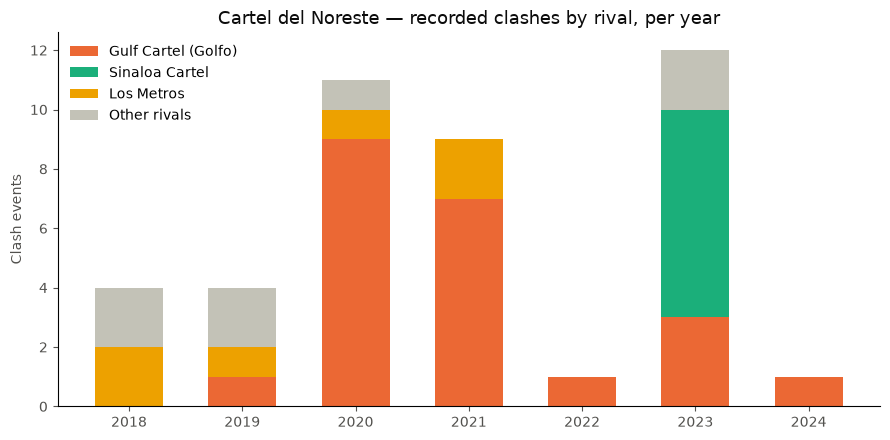

rival_bucket,Gulf Cartel (Golfo),Sinaloa Cartel,Los Metros,Other rivals
year,,,,
2018,0,0,2,2
2019,1,0,1,2
2020,9,0,1,1
2021,7,0,2,0
2022,1,0,0,0
2023,3,7,0,2
2024,1,0,0,0


In [ ]:
cdn_rivals = cartel_rivals_by_year("Cartel del Noreste")
plot_rivals_bar("Cartel del Noreste", cdn_rivals)
cdn_rivals

Roughly 88% of Cartel del Noreste's recorded violent activity is concentrated in three neighboring northeastern states — Tamaulipas, Nuevo León, Coahuila — the Zetas' historical territory the group split from. Its defining rivalry is with Gulf Cartel (Golfo), peaking at 9 clashes in 2020 and 7 in 2021, then largely dying out; a brief, separate flare-up against Sinaloa Cartel appears in 2023. By 2024, recorded events have fallen to 12 (from a peak of 38 in 2020), fatalities to 15 (from 111 in 2019), and its footprint has narrowed to just 3 states. Where CJNG's arc is expansion, this reads as a regional war that peaked in 2020–2021 and has since been losing intensity — consistent with, though not proof of, a weakened or degraded organization. ACLED records reported events, not underlying cartel strength, so a falling count could also reflect reduced press coverage in the region.

## 5. Summary

Two different stories come out of the same pipeline:

- **CJNG** is the network's constant center — nationally present every year, its rival roster turning over as it opens new fronts, consolidating by 2024 into an escalating, near-exclusive war with Sinaloa Cartel.
- **Cartel del Noreste** is a regional actor with one dominant rival (Gulf Cartel) whose conflict peaked in 2020–2021 and has visibly cooled since.

Both are visible only because the underlying data structure is temporal — a `(year, cartel_a, cartel_b, weight)` edge list — rather than the single static snapshot BACRIM2020 provides. The cross-check in §2 showed the two sources agree on *who* the major rivalries are; ACLED is what adds *when*.

**Caveats worth keeping in mind:**
- Name normalization (§2) is a heuristic over free-text actor names, not verified entity resolution — it will miss some aliases and occasionally split or merge factions incorrectly.
- The single largest actor1 category in the raw Mexico data is `"Unidentified Gang/Armed Group"` (tens of thousands of events) — excluded here because it can't be attributed to a specific cartel. The named-cartel network is a *lower bound* on total cartel violence, not a full census.
- ACLED events are journalist- and press-sourced; a rise or fall in recorded events can reflect changes in media coverage as well as changes in actual violence.
- The network is capped to cartels with ≥3 recorded clashes 2018–2024 (36 of them) to keep the figures legible — smaller or newer factions are undercounted by construction.